Análise de Desempenho de Algoritmo k-NN na Predição de Doença Renal Crônica 
=====================================

**Entrega escolhida:** Criatura Lendária "Cubo Gelatinoso" <br>
**Autoria:** Giovanna Avellar Machado <br>
**Disciplina:** Aprendizado de Máquina - 2º Semestre T26 <br>
**Docente:** Daniel Roberto Cassar <br>
**Instituição:** Ilum - Escola de Ciência

## Índice

1. [Introdução](#intro)
2. [Metodologia](#metodologia)
3. [Desenvolvimento](#desenvolvimento)
4. [Conclusões e Principais Aprendizados](#conclusao)
5. [Descrição do uso de IA neste trabalho](#interacao)
6. [Referências](#refs)

<a id="intro"></a>
## 1. Introdução

$ \ \ \ \ \ $ O presente trabalho busca estudar o desempenho de um modelo induzido pelo algoritmo dos k-vizinhos mais próximos (k-NN, k-Nearest Neighbors) em um conjunto de dados que contém informações sobre Doença Renal Crônica (DRC), considerando diferentes conjuntos de hiperparâmetros, analisando seu impacto sobre as predições realizadas. 

$ \ \ \ \ \ $ A Doença Renal Crônica consiste na perda lenta, gradual e irreversível da capacidade dos rins de filtrar toxinas, controlar líquidos e regular eletrólitos do sangue por mais de três meses, através da perda de néfrons de forma permanente. Diante de sua importância vital para o organismo, causa extrema preocupação um recente levantamento, publicado pelo The Lancet [[1]](#refs)., que aponta que 1,5 milhão de pessoas morrem todos os anos por doença renal crônica, indicando um aumento de mais de 6% em relação a 1993, mesmo considerando diferenças etárias entre países. Segundo o periódico, cerca de 14% dos adultos no mundo têm a doença. Além disso, o número de pessoas com função renal comprometida atingiu um recorde mundial: pulou de 378 milhões registrados em 1990 para 788 milhões em 2023. O crescimento significativo de quase o dobro acompanha o envelhecimento da população e posiciona a DRC no 9º lugar como causa de morte no mundo, atestando que a doença está se tornando um problema concreto de saúde pública, apesar de a OMS apontar que a grande maioria dos portadores nos estágios iniciais desconheça o problema, o que a torna uma doença silenciosa e faz com que o número seja, na realidade, maior que o registrado.

$ \ \ \ \ \ $ Contudo, muitos casos diagnosticados precocemente podem ter sua progressão retardada e seus impactos reduzidos por meio de medicamentos, acompanhamento médico e mudanças no estilo de vida. Dessa forma, o Aprendizado de Máquina, especialmente no desenvolvimento de modelos preditivos interpretáveis, caracteriza-se como um importante aliado da área da saúde, contribuindo para a identificação precoce de indivíduos com maior risco de desenvolver a doença. Ao analisar padrões presentes em dados clínicos e laboratoriais, esses modelos podem auxiliar profissionais da saúde na tomada de decisão, colaborando para o enfrentamento da subnotificação e para a ampliação das estratégias de diagnóstico precoce da Doença Renal Crônica.

$ \ \ \ \ \ $ Com esse objetivo em mente, foi desenvolvido um modelo induzido pelo algorimo k-NN que foi treinado com um conjunto de dados, coletado em ambiente hospitalar ao longo de aproximadamente dois meses, contendo informações clínicas e laboratoriais de 400 pacientes. O DataSet foi obtido por meio do Chronic Kidney Disease, disponibilizado pelo UCI Machine Learning Repository [[2]](#refs), e apresenta 24 atributos preditores e um target que classifica os pacientes em portadores de Doença Renal Crônica (ckd) ou não portadores (notckd). Desses atributos, 11 são numéricos: idade (anos), pressão arterial (mm/Hg), glicemia aleatória (mg/dL), ureia sanguínea (mg/dL), creatinina sérica (mg/dL) - relacionada ao cálculo da Taxa de Filtração Glomerular (TFG) -, sódio (mEq/L), potássio (mEq/L), hemoglobina (g/dL), volume globular, contagem de leucócitos (células/mm³) e contagem de hemácias (milhões/mm³). Os 13 atributos categóricos restantes representam informações clínicas relacionadas a exames de urina e ao estado geral do paciente, incluindo densidade específica, albumina, glicose urinária, presença de bactérias, hipertensão, diabetes mellitus, doença arterial coronariana, apetite, edema e anemia.

<a id="metodologia"></a>
## 2. Metodologia

$ \ \ \ \ \ $ $ \ \ \ \ \ $ Para o desenvolvimento deste trabalho, foram importadas diversas bibliotecas da linguagem Python. A biblioteca `Pandas` foi utilizada para a leitura, organização e manipulação do conjunto de dados. As bibliotecas `NumPy` e `Statistics` foram empregadas na realização de cálculos numéricos e estatísticos, auxiliando na obtenção de medidas descritivas e na análise dos dados. A biblioteca `Matplotlib`, por meio do módulo `pyplot`, foi utilizada para a construção e personalização dos gráficos apresentados, enquanto a biblioteca `Seaborn` foi empregada na elaboração de visualizações estatísticas mais elaboradas e informativas. Por fim, foram importados diversos métodos do `scikit-learn`, para realizar a implementação dos modelos, a divisão treino-teste e o cálculo das métricas de desempenho.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

$ \ \ \ \ \ $  Para importar o DataSet "Chronic Kidney Disease" do UCI Machine Learning Repository [[n]](#referencias), seguiu-se a orientação disponibilizada no site do Repositório para rodar as seguintes células:

In [2]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [4]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
chronic_kidney_disease = fetch_ucirepo(id=336) 
  
# data (as pandas dataframes) 
X = chronic_kidney_disease.data.features 
y = chronic_kidney_disease.data.targets 

# metadata 
print(chronic_kidney_disease.metadata) 
  
# variable information 
print(chronic_kidney_disease.variables) 

{'uci_id': 336, 'name': 'Chronic Kidney Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/336/data.csv', 'abstract': 'This dataset can be used to predict the chronic kidney disease and it can be collected from the hospital nearly 2 months of period.', 'area': 'Other', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 400, 'num_features': 24, 'feature_types': ['Real'], 'demographics': ['Age'], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2015, 'last_updated': 'Mon Mar 04 2024', 'dataset_doi': '10.24432/C5G020', 'creators': ['L. Rubini', 'P. Soundarapandian', 'P. Eswaran'], 'intro_paper': None, 'additional_info': {'summary': 'We use the following representation to collect the dataset\r\n                        age\t\t-\tage\t\r\n\t\t\tbp\t\t-\tblood pressure\r\n\t\t\tsg\t

$ \ \ \ \ \ $ Para realizar a concatenação das colunas de X com a coluna y, utiliza-se o método `.concat()`, em que o argumento `axis=1` indica que a concatenação será feita horizonatlmente, ou seja, adicionando as colunas lado a lado. Dessa forma, os atributos preditores e a variável alvo são reunidos em um único *DataFrame*, facilitando sua visualização e análise. Com isso feito, o método `.head()` é utilizado para exibir as cinco primeiras linhas desse conjunto de dados, permitindo verificar rapidamente se a concatenação ocorreu corretamente.

In [5]:
df = pd.concat([X, y], axis=1)
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


<a id="desenvolvimento"></a>
## 3. Desenvolvimento

### Pré-Processamento de Dados

$ \ \ \ \ \ $ Antes de qualquer alteração no DataFrame, é importante ter clareza sobre a quantidade de dados disponíveis para a sua análise. Para isso, utilizou-se o método `.shape()`, que informa o número de observações e de atributos presentes no conjunto de dados. Além disso, o método `.columns.tolist()` foi utilizado para listar todas as variáveis disponíveis, permitindo verificar a estrutura do conjunto de dados e garantir que os atributos clínicos e laboratoriais de interesse foram importados corretamente.
Mostrar mais linhas

In [6]:
print(df.shape)
print(df.columns.tolist())

(400, 25)
['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'class']


$ \ \ \ \ \ $ Objetivando traduzir os nomes dos atributos para português, e deixá-los mais facilmente reconhecíveis sem as siglas originais do conjunto de dados, foi utilizado o método `rename()`. Em seguida, foi utilizado novamente o método `.head()`. Vale comentar que foi optado por não adicionar as unidades de medida dos atributos, a fim de tornar a visualização mais simples e organizada.

In [7]:
df = pd.concat([X, y], axis=1)

df = df.rename(columns={
    'age': 'idade',
    'bp': 'pressao_arterial',
    'sg': 'gravidade_especifica',
    'al': 'albumina',
    'su': 'acucar',
    'rbc': 'globulos_vermelhos',
    'pc': 'celulas_pus',
    'pcc': 'aglomerados_celulas_pus',
    'ba': 'bacterias',
    'bgr': 'glicose_aleatoria_sangue',
    'bu': 'ureia_sanguinea',
    'sc': 'creatinina_serica',
    'sod': 'sodio',
    'pot': 'potassio',
    'hemo': 'hemoglobina',
    'pcv': 'volume_celular_empacotado',
    'wbcc': 'contagem_leucocitos',
    'rbcc': 'contagem_eritrocitos',
    'htn': 'hipertensao',
    'dm': 'diabetes_mellitus',
    'cad': 'doenca_arterial_coronariana',
    'appet': 'apetite',
    'pe': 'edema_pedal',
    'ane': 'anemia',
    'class': 'classificacao'
})

df.head()

,idade,pressao_arterial,gravidade_especifica,albumina,acucar,globulos_vermelhos,celulas_pus,aglomerados_celulas_pus,bacterias,glicose_aleatoria_sangue,...,volume_celular_empacotado,contagem_leucocitos,contagem_eritrocitos,hipertensao,diabetes_mellitus,doenca_arterial_coronariana,apetite,edema_pedal,anemia,classificacao
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


$ \ \ \ \ \ $ Outra boa prática antes de se iniciar qualquer alteração no DataFrame é se perguntar se os dados que estão sendo analisados possuem valores faltantes, uma vez que é comum um conjunto de dados ter certas entradas indisponíveis, de modo que faz parte do pré-processamento de dados identificar e tratar esse tipo de problema. Nesse sentido, embora o UCI Machine Learning Repository informe a presença desses chamados "missing values", ao rodar o código apenas com o nome do DataFrame, permitindo a visualização das 5 primeiras e 5 últimas linhas, é possível identificar a ocorrência de valores ausentes representados por `NaN` (Not a Number) em algumas variáveis do conjunto de dados. Como há uma grande quantidade de colunas, procedimentos adicionais foram necessários para identificar a ocorrência de valores ausentes em cada atributo, utilizando o método `.set_option`.

In [8]:
pd.set_option('display.max_columns', None)
df

,idade,pressao_arterial,gravidade_especifica,albumina,acucar,globulos_vermelhos,celulas_pus,aglomerados_celulas_pus,bacterias,glicose_aleatoria_sangue,ureia_sanguinea,creatinina_serica,sodio,potassio,hemoglobina,volume_celular_empacotado,contagem_leucocitos,contagem_eritrocitos,hipertensao,diabetes_mellitus,doenca_arterial_coronariana,apetite,edema_pedal,anemia,classificacao
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35.0,7300.0,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,49.0,0.5,150.0,4.9,15.7,47.0,6700.0,4.9,no,no,no,good,no,no,notckd
396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,31.0,1.2,141.0,3.5,16.5,54.0,7800.0,6.2,no,no,no,good,no,no,notckd
397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,26.0,0.6,137.0,4.4,15.8,49.0,6600.0,5.4,no,no,no,good,no,no,notckd
398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,50.0,1.0,135.0,4.9,14.2,51.0,7200.0,5.9,no,no,no,good,no,no,notckd


$ \ \ \ \ \ $ Com o objetivo de identificar quantos dados faltantes havia em cada coluna, foi utilizado o método `.isnull().sum()`, e, em seguida, o `.sort_values` que coloca as colunas em ordem decrescente com relação à essa quantidade de dados faltantes. 

In [9]:
df.isnull().sum()
df.isnull().sum().sort_values(ascending=False)

globulos_vermelhos             152
contagem_eritrocitos           131
contagem_leucocitos            106
potassio                        88
sodio                           87
volume_celular_empacotado       71
celulas_pus                     65
hemoglobina                     52
acucar                          49
gravidade_especifica            47
albumina                        46
glicose_aleatoria_sangue        44
ureia_sanguinea                 19
creatinina_serica               17
pressao_arterial                12
idade                            9
aglomerados_celulas_pus          4
bacterias                        4
hipertensao                      2
diabetes_mellitus                2
doenca_arterial_coronariana      2
apetite                          1
edema_pedal                      1
anemia                           1
classificacao                    0
dtype: int64

$ \ \ \ \ \ $ Buscando identificar de forma mais evidente a distribuição dos valores faltantes ao longo do conjunto de dados, foi plotado um mapa de calor utilizando o método .heatmap() da biblioteca Seaborn, aplicado sobre o resultado do método .isnull(). Esse método retorna uma matriz booleana de mesmo formato do DataFrame original, na qual cada célula indica se o respectivo valor é ausente (True) ou presente (False). No gráfico, cada linha representa um paciente e cada coluna um atributo, de modo que a cor vermelha indica a ausência do dado naquela posição, enquanto a cor cinza indica que o valor está presente. Essa representação permite visualizar rapidamente tanto a proporção de valores faltantes em cada atributo quanto possíveis padrões de ausência entre diferentes variáveis — por exemplo, observa-se que atributos como globulos_vermelhos, celulas_pus e contagem_eritrocitos concentram uma quantidade expressiva de dados faltantes, enquanto atributos categóricos como hipertensao, diabetes_mellitus e apetite apresentam poucos ou nenhum valor ausente. !

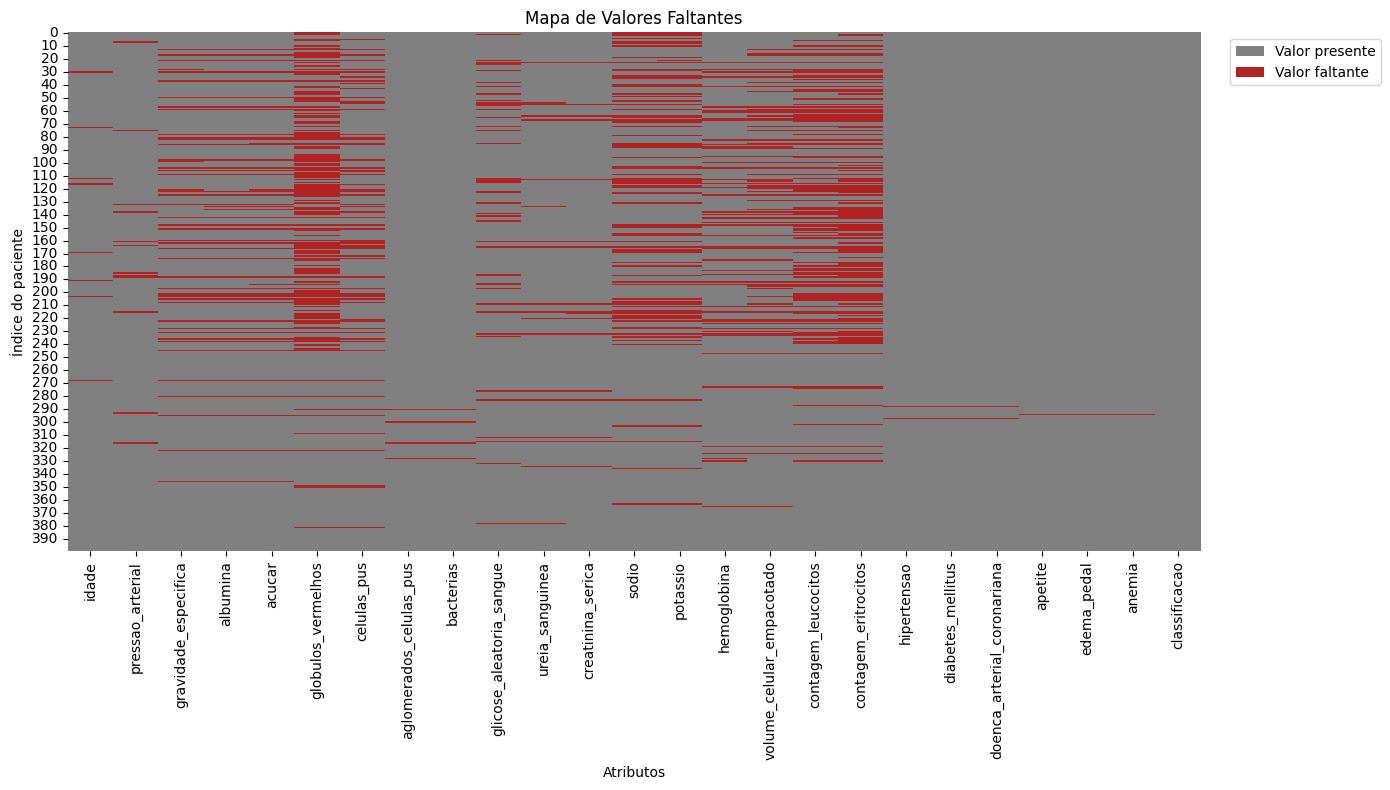

In [10]:
plt.figure(figsize=(14, 8))
sns.heatmap(df.isnull(), cbar=False, cmap=["grey", "firebrick"])
plt.title("Mapa de Valores Faltantes")
plt.xlabel("Atributos")
plt.ylabel("Índice do paciente")
plt.xticks(rotation=90)

from matplotlib.patches import Patch
legenda = [
    Patch(facecolor="grey", label="Valor presente"),
    Patch(facecolor="firebrick", label="Valor faltante")
]
plt.legend(handles=legenda, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

$ \ \ \ \ \ $ Os espaços em branco presentes nos valores do atributo-alvo `classificacao` foram removidos por meio do método `.str.strip()`. Além disso, para se ter uma noção da distribuição dos rótulos das variáveis categóricas binárias, levando em consideração se o paciente em questão possui ou não a doença, foram plotados 10 gráficos de barras, um para cada atributo, utilizando a biblioteca Matplotlib. Para isso, o método pd.crosstab() foi utilizado para contabilizar, dentro de cada classe do target (ckd e notckd), quantos pacientes apresentam cada categoria do atributo em questão (por exemplo, quantos pacientes com ckd têm hipertensão e quantos não têm). As barras em vermelho representam a categoria associada à presença de uma condição ou resultado anormal (como "abnormal", "present" ou "yes"), enquanto as barras em azul escuro representam a categoria oposta, permitindo identificar visualmente quais atributos categóricos apresentam distribuições mais distintas entre as duas classes do target.

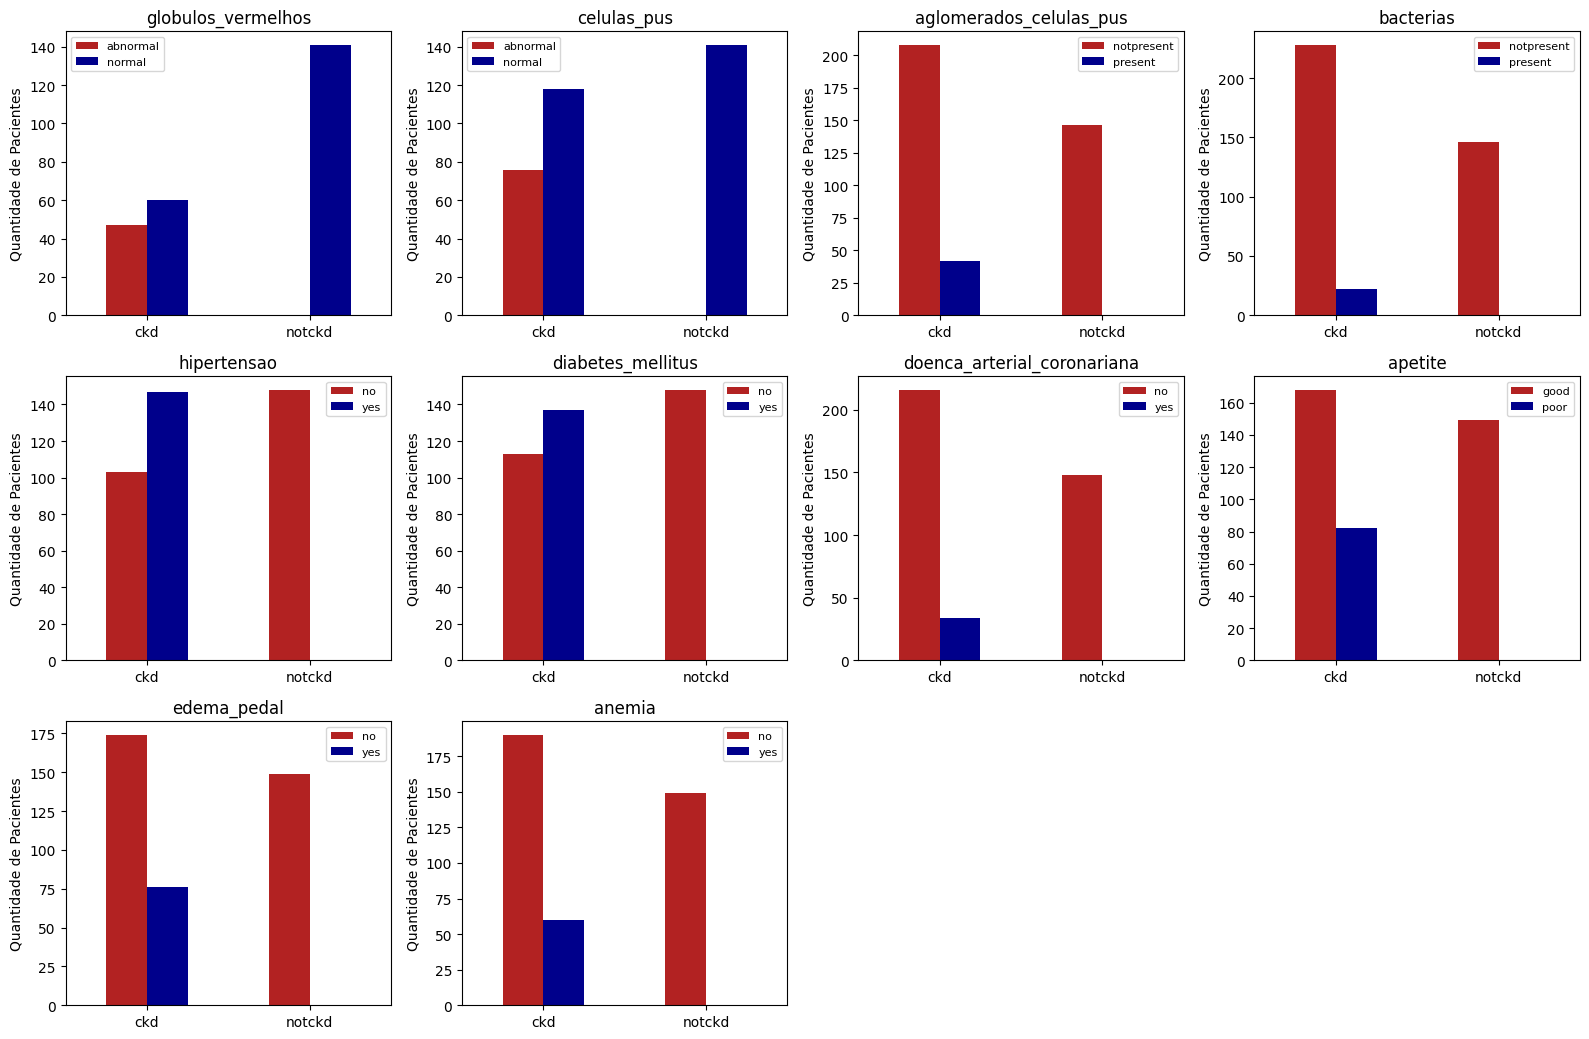

In [11]:
colunas_categoricas = df.select_dtypes(include=["object"]).columns.drop("classificacao") 
for col in colunas_categoricas:
    df[col] = df[col].str.strip() 
    
df["classificacao"] = df["classificacao"].str.strip()

 
colunas_categoricas_dist = df.select_dtypes(include=["object"]).columns.drop("classificacao")
 
n_colunas = 4
n_linhas = -(-len(colunas_categoricas_dist) // n_colunas)
 
fig, eixos = plt.subplots(n_linhas, n_colunas, figsize=(n_colunas*4, n_linhas*3.5))
eixos = eixos.flatten()
 
for i, coluna in enumerate(colunas_categoricas_dist):
    tabela = pd.crosstab(df["classificacao"], df[coluna])
    tabela.plot(kind="bar", ax=eixos[i], color=["firebrick", "darkblue"])
    eixos[i].set_title(coluna)
    eixos[i].set_xlabel("")
    eixos[i].set_ylabel("Quantidade de Pacientes")
    eixos[i].tick_params(axis="x", rotation=0)
    eixos[i].legend(fontsize=8)
 
for j in range(len(colunas_categoricas_dist), len(eixos)):
    fig.delaxes(eixos[j])
 
plt.tight_layout()
plt.show()

$ \ \ \ \ \ $ De forma análoga, para a análise dos atribuos numéricos, foram plotados 14 boxplots, utilizando tanto a biblioteca `seaborn` quanto a `Matplotib`. Cada boxplot foi construído separando os pacientes de acordo com a classe do target, permitindo visualizar, para cada atributo, a mediana, a dispersão e a presença de possíveis valores anômalos, também chamados de outliers, em cada um dos dois grupos. 
$ \ \ \ \ \ $ A representação dos dados dessa forma, busca identificar quais atributos numéricos apresentam distribuições visivelmente distintas entre pacientes com e sem a doença — como é o caso, por exemplo, da hemoglobina e do volume celular empacotado, cujos valores tendem a ser mais baixos em pacientes com DRC, o que é coerente com a anemia frequentemente associada a quadros de insuficiência renal — enquanto outros atributos apresentam maior sobreposição entre as classes, indicando menor capacidade discriminativa individual. Isso será crucial para fazer a seleção de quais atributos serão utlizados no modelo posteriormente.

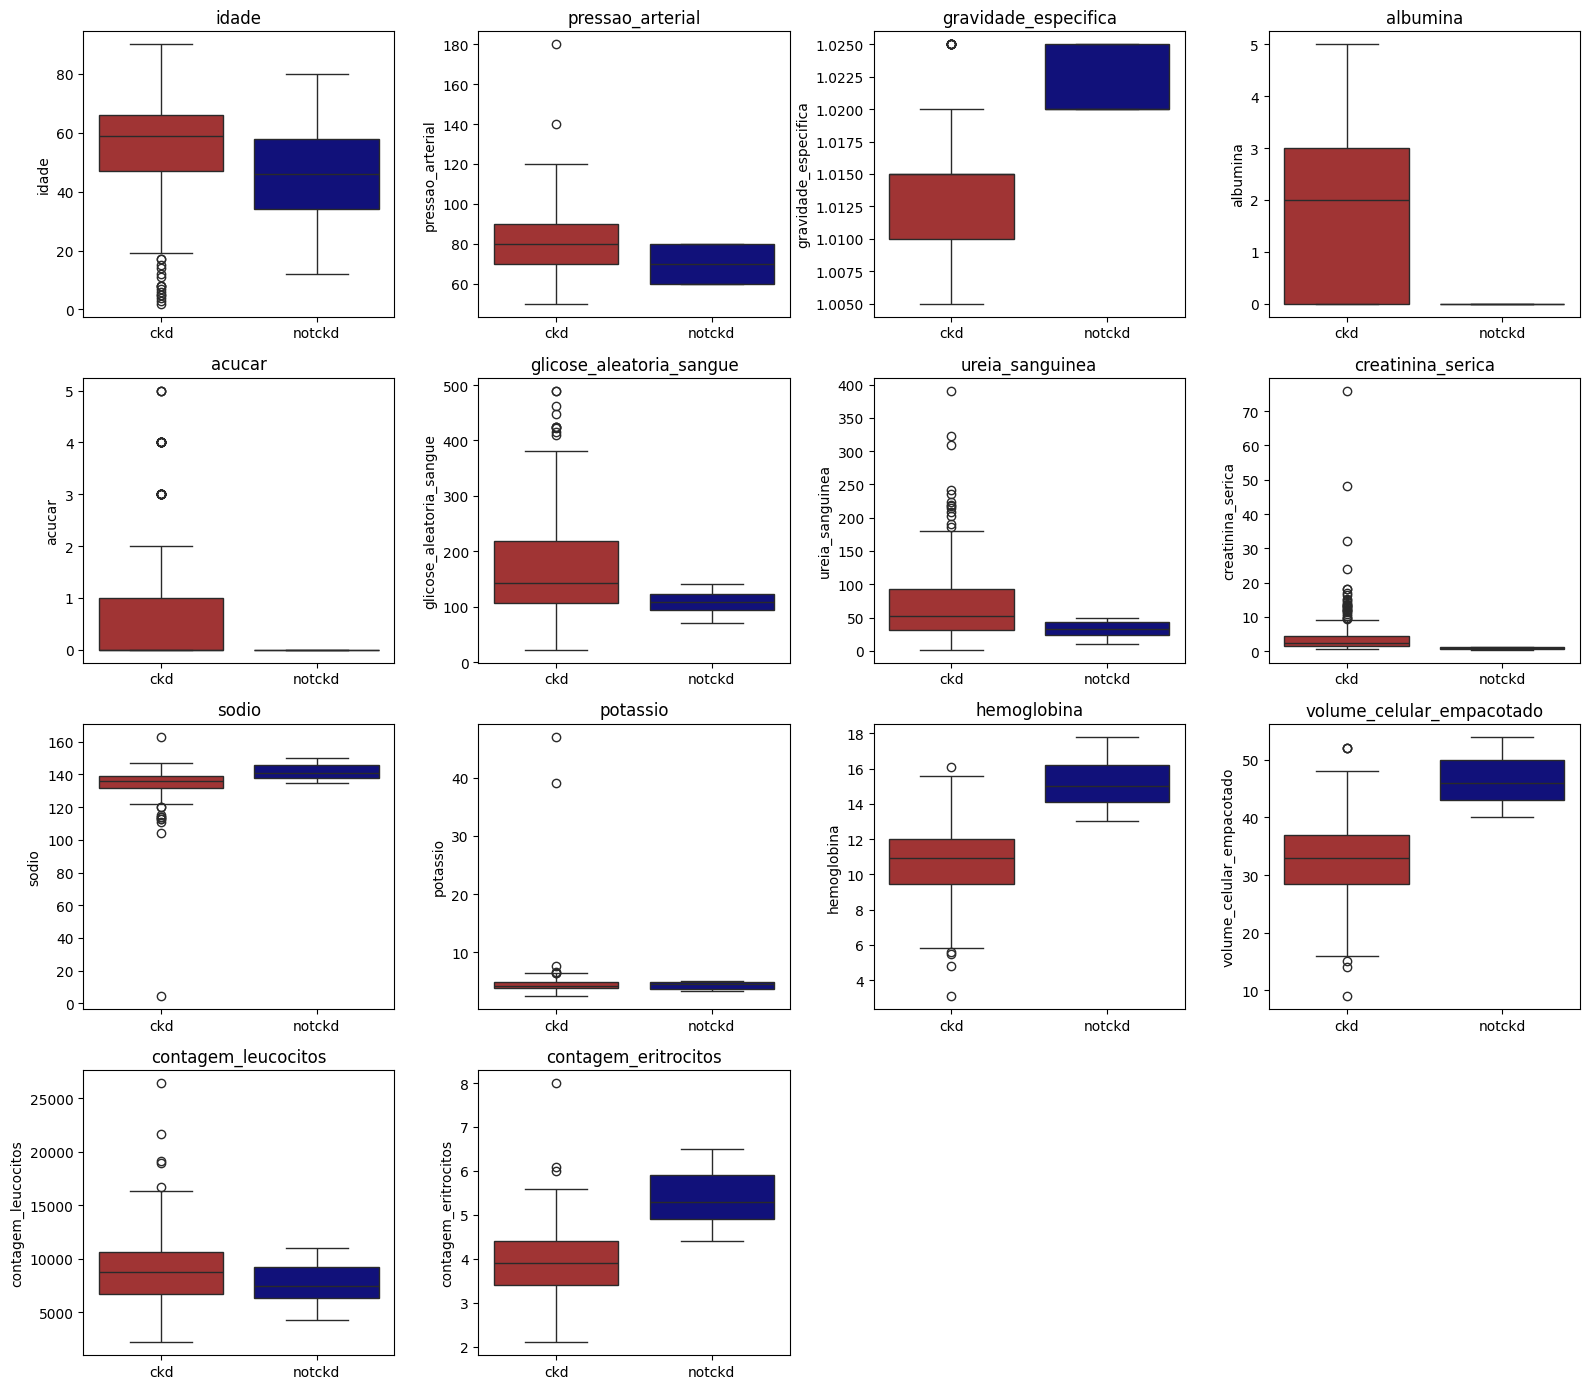

In [12]:
colunas_numericas_plot = df.select_dtypes(include=["float64", "int64"]).columns
 
n_colunas = 4
n_linhas = -(-len(colunas_numericas_plot) // n_colunas)  # arredonda para cima
 
fig, eixos = plt.subplots(n_linhas, n_colunas, figsize=(n_colunas * 4, n_linhas * 3.5))

eixos = eixos.flatten()
for i, coluna in enumerate(colunas_numericas_plot):
    sns.boxplot(
        data=df, x="classificacao", y=coluna, hue="classificacao", ax=eixos[i],
        palette={"ckd": "firebrick", "notckd": "darkblue"}, legend=False
    )
    eixos[i].set_title(coluna)
    eixos[i].set_xlabel("")
 
for j in range(len(colunas_numericas_plot), len(eixos)):
    fig.delaxes(eixos[j])
 
plt.tight_layout()
plt.show()

$ \ \ \ \ \ $ Com essa análise exploratória tendo sido feita, agora podemos transformar o DataSet para sua utlização. Contudo, com o objetivo de preservar os dados antes das transformações, foi criada uma cópia do DataFrame original utilizando o método `.copy()`. Em seguida, as variáveis categóricas binárias foram então convertidas em variáveis numéricas por meio da implementação do método `.map()`. As categorias "normal", "present", "yes" e "good" foram representadas por 1, enquanto "abnormal", "notpresent", "no" e "poor" foram representadas por 0. Essa codificação binária manual permite que as variáveis sejam utilizadas nos cálculos de distância realizados pelo algoritmo k-NN.

In [13]:
df_copia = df.copy()
colunas_para_remover = ["globulos_vermelhos", "contagem_leucocitos", "potassio", "sodio"]
print(df_copia.drop(columns=colunas_para_remover).dropna().shape)

(210, 21)


In [14]:
df_copia["globulos_vermelhos"] = df_copia["globulos_vermelhos"].map({
    "normal": 1,
    "abnormal": 0
})

df_copia["celulas_pus"] = df_copia["celulas_pus"].map({
    "normal": 1,
    "abnormal": 0
})

df_copia["aglomerados_celulas_pus"] = df_copia["aglomerados_celulas_pus"].map({
    "present": 1,
    "notpresent": 0
})

df_copia["bacterias"] = df_copia["bacterias"].map({
    "present": 1,
    "notpresent": 0
})

df_copia["hipertensao"] = df_copia["hipertensao"].map({
    "yes": 1,
    "no": 0
})

df_copia["diabetes_mellitus"] = df_copia["diabetes_mellitus"].map({
    "yes": 1,
    "no": 0
})

df_copia["doenca_arterial_coronariana"] = df_copia["doenca_arterial_coronariana"].map({
    "yes": 1,
    "no": 0
})

df_copia["apetite"] = df_copia["apetite"].map({
    "good": 1,
    "poor": 0
})

df_copia["edema_pedal"] = df_copia["edema_pedal"].map({
    "yes": 1,
    "no": 0
})

df_copia["anemia"] = df_copia["anemia"].map({
    "yes": 1,
    "no": 0
})

$ \ \ \ \ \ $ Também foi decidido que seriam retiradas algumas colunas em que havia muitos dados faltantes, para que, ao utilizar o método `dropna()`, não fossem perdidos muitos dados nas linhas restantes. A partir do Mapa de Valores Faltantes e do uso do método `.isnull()`, foi possível observar que os atributos globulos_vermelhos, contagem_leucocitos, potassio e sodio apresentavam consideravelmente mais dados faltantes do que os demais, motivo pelo qual foram removidos do conjunto de dados antes da remoção das linhas incompletas.

In [15]:
colunas_para_remover = ["globulos_vermelhos", "contagem_leucocitos", "potassio", "sodio"]

df_copia = df_copia.drop(columns=colunas_para_remover)
df_copia = df_copia.dropna()

print(df_copia.shape)

(210, 21)


$ \ \ \ \ \ $ Por fim, foi realizada a codificação binária dessa variável, atribuindo-se o valor 1 à categoria **ckd**, que indica a presença de doença renal crônica, e o valor 0 à categoria **notckd**, que representa sua ausência. Essa conversão possibilitou a utilização da variável-alvo durante o treinamento e a avaliação do modelo de classificação.

In [16]:
ordem_labels = df["classificacao"].unique().tolist()
ordem_labels

['ckd', 'notckd']

$ \ \ \ \ \ $ Com o objetivo de compreender se as classificações do target estavam desbalanceadas, foi plotado um gráfico que representa a distribuição dos rótulos do target utilizando a biblioteca `Matplotlib`.  

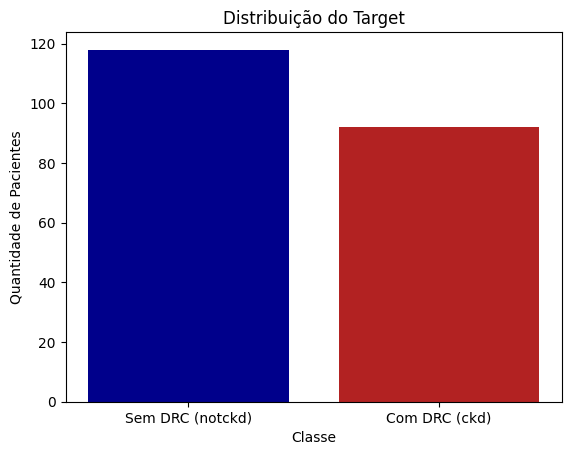

In [31]:
contagem_classes = df_copia["classificacao"].value_counts()

cores = {"ckd": "firebrick", "notckd": "darkblue"}
rotulos_legiveis = {"ckd": "Com DRC (ckd)", "notckd": "Sem DRC (notckd)"}

fig, ax = plt.subplots()
barras = ax.bar(
    contagem_classes.index,
    contagem_classes.values,
    color=[cores[classe] for classe in contagem_classes.index]
)

ax.set_xticks(range(len(contagem_classes.index)))
ax.set_xticklabels([rotulos_legiveis[classe] for classe in contagem_classes.index])
ax.set_xlabel("Classe")
ax.set_ylabel("Quantidade de Pacientes")
ax.set_title("Distribuição do Target")

plt.show()

$ \ \ \ \ \ $ A partir da análise do gráfico, observou-se que o DataSet apresenta um certo desbalanceamento entre as classes, com a categoria **ckd** sendo a mais frequente. Esse desbalanceamento é relevante para a interpretação dos resultados do modelo, uma vez que métricas como a acurácia podem ser enganosas em conjuntos de dados desbalanceados. Um modelo que sempre prevê a classe majoritária, como o baseline, tende a apresentar uma acurácia alta mesmo sem aprender nenhum padrão real.

### Separação dos Dados de Treino e Teste

$ \ \ \ \ \ $ Uma etapa fundamental que deve ser feita antes do desenvolvimento de qualquer modelo de Aprendizado de Máquina é a Estratégia de Holdout, também chamada de divisão em treino e teste (train-test split). Essa técnica consiste em separar o conjunto de dados em duas partes: uma destinada ao treinamento do modelo e outra reservada para sua avaliação. 

$ \ \ \ \ \ $ Os dados de treinamento correspondem às observações utilizadas pelo algoritmo durante o processo de aprendizagem, permitindo o ajuste de seus parâmetros internos. Já os dados de teste permanecem ocultos durante o treinamento e são utilizados posteriormente para avaliar a capacidade de generalização do modelo, isto é, sua habilidade de realizar previsões corretas para dados que não foram vistos anteriormente, sem que haja sobreajuste.

$ \ \ \ \ \ $ Para a implementação do código, deve-se importar a função `train_test_split` do módulo `scikit-learn` e definir quanto dos dados vamos reservar para o conjunto de teste. Nesse caso, 20% dos dados serão reservados para o treino, enquanto que os 80% restantes serão utilizados para o teste. Além disso, vale ressaltar que foi definida uma semente aleatória que mantém a reprodutibilidade dos resultados obtidos, passando o seu valor para o argumento `random_state`, garantindo que o conjunto de treino e teste será sempre o mesmo.

In [32]:
from sklearn.model_selection import train_test_split

TAMANHO_TESTE = 0.2
SEMENTE_ALEATORIA = 140
TARGET = "classificacao"

indices = df_copia.index
indices_treino, indices_teste = train_test_split(
    indices, test_size=TAMANHO_TESTE, random_state=SEMENTE_ALEATORIA,  stratify=df_copia[TARGET]
)

df_treino = df_copia.loc[indices_treino]
df_teste = df_copia.loc[indices_teste]

print(df_treino.shape, df_teste.shape)

(168, 21) (42, 21)


### Escolha e Treino de um Modelo Preditivo

In [33]:
ATRIBUTOS = ["gravidade_especifica",    "albumina",    "hemoglobina",    "creatinina_serica",    "hipertensao",    "diabetes_mellitus",    "glicose_aleatoria_sangue",    "apetite", ]

X_treino = df_treino[ATRIBUTOS].values
X_teste = df_teste[ATRIBUTOS].values
y_treino = df_treino[TARGET].values
y_teste = df_teste[TARGET].values

### Modelo de Classificação: Baseline

$ \ \ \ \ \ $ O Modelo Baseline, também chamado de dummy, linha de base ou modelo fictício, é um modelo muito simples que é utilizado para comparar o desempenho de modelos mais complexos. Empregando a estratégia da classe majoritária, o classificador realiza suas previsões atribuindo sempre a categoria mais frequente observada no conjunto de treinamento, ou seja, a moda do target. Para implementá-lo, é necessário importar a classe `DummyClassifier`, fazer uma instância e, em seguida, um ajuste `.fit()`.

In [34]:
from sklearn.dummy import DummyClassifier

modelo_baseline = DummyClassifier()
modelo_baseline.fit(X_treino, y_treino) 

,strategy,'prior'
,random_state,None
,constant,None


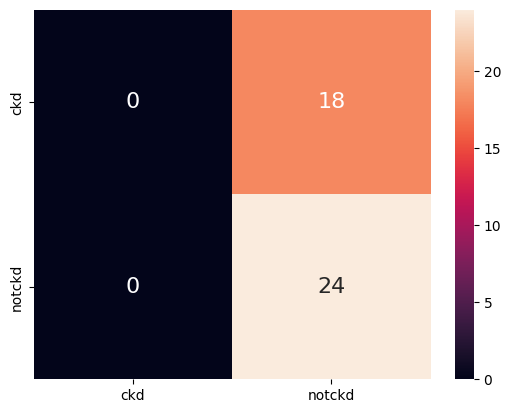

In [35]:
from sklearn.metrics import confusion_matrix

y_verdadeiro = y_teste
y_previsao = modelo_baseline.predict(X_teste)

matriz_conf = confusion_matrix(y_verdadeiro, y_previsao, labels=ordem_labels)
df_conf = pd.DataFrame(matriz_conf, ordem_labels, ordem_labels)

sns.heatmap(df_conf, annot=True, annot_kws={"size": 16});

In [36]:
from sklearn.metrics import accuracy_score

acuracia_baseline = accuracy_score(y_verdadeiro, y_previsao)

print(f"Acurácia do Modelo Baseline: {(acuracia_baseline*100):.2f}%")

Acurácia do Modelo Baseline: 57.14%


$ \ \ \ \ \ $ Uma acurácia de 57,14% reflete a distribuição dos rótulos do target, uma vez que o DummyClassifier prevê sempre a classe majoritária observada no conjunto de treinamento. Entretanto, percebe-se uma pequena divergência entre esse valor e a proporção geral das classes no conjunto de dados completo. Essa diferença decorre da aleatoriedade inerente ao processo de divisão dos dados: embora o parâmetro stratify busque preservar a proporção original das classes tanto no conjunto de treino quanto no de teste, essa preservação é apenas aproximada, já que o número de pacientes em cada subconjunto é finito e não permite uma divisão exatamente proporcional. Além disso, a divisão específica obtida depende da semente aleatória (random_state) utilizada, de modo que diferentes valores de semente resultariam em subconjuntos de treino e teste distintos, e, consequentemente, em pequenas variações na acurácia do modelo baseline.

### Modelo de Classificação: k-vizinhos mais próximos

$ \ \ \ \ \ $ O algoritmo de k-vizinhos mais próximos é um algoritmo supervisionado de classificação baseado na proximidade entre exemplos, em que a classe de uma observação é determinada a partir das classes de seus vizinhos mais próximos. 

In [41]:
NUM_VIZINHOS = 3

modelo_knn = KNeighborsClassifier(NUM_VIZINHOS)
modelo_knn.fit(X_treino, y_treino)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


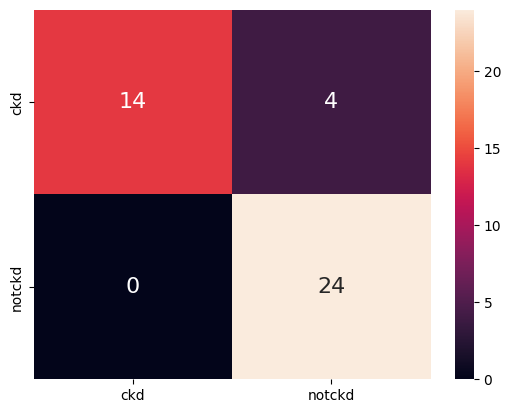

In [40]:
y_verdadeiro_knn = y_teste
y_previsao_knn = modelo_knn.predict(X_teste)

matriz_conf = confusion_matrix(y_verdadeiro_knn, y_previsao_knn, labels=ordem_labels)
df_conf = pd.DataFrame(matriz_conf, ordem_labels, ordem_labels)

sns.heatmap(df_conf, annot=True, annot_kws={"size": 16});

### Métricas de Desempenho

In [44]:
acuracia = accuracy_score(y_verdadeiro_knn, y_previsao_knn)
print(f"Acurácia do modelo: {(acuracia*100):.2f}%")

Acurácia do modelo: 90.48%


$ \ \ \ \ \ $ A acurácia desse modelo foi superior à do baseline em 33,14%. Isso se dá devido ao fato de o modelo baseline realizar suas previsões de forma ingênua, atribuindo sempre a classe majoritária observada no treinamento, independentemente das características de cada paciente. O algoritmo k-NN, por sua vez, utiliza efetivamente os atributos clínicos disponíveis — como hemoglobina, albumina e gravidade específica — para calcular a distância entre um novo paciente e seus vizinhos mais próximos no conjunto de treinamento, classificando-o de acordo com a categoria predominante entre esses vizinhos. Como diversos desses atributos apresentam diferenças relevantes entre as classes ckd e notckd (conforme observado na análise exploratória por meio dos boxplots), o modelo consegue capturar padrões reais presentes nos dados, resultando em uma capacidade de classificação significativamente superior à de um modelo que não considera nenhuma informação individual do paciente.

$ \ \ \ \ \ $ Embora a acurácia seja uma métrica de desempenho extremamente útil, há outras métricas que podem ser utilizadas. 

In [26]:
from sklearn.metrics import recall_score
recall = recall_score(y_verdadeiro_knn, y_previsao_knn, pos_label='ckd')
print(recall)

0.7857142857142857


O modelo apresentou recall de 86,49% para a classe associada à Doença Renal Crônica. Isso significa que aproximadamente 86% dos pacientes realmente portadores da doença foram corretamente identificados pelo algoritmo, enquanto cerca de 14% foram classificados incorretamente como não portadores. Em aplicações médicas, essa métrica é particularmente relevante, pois avalia a capacidade do modelo de detectar indivíduos doentes e minimizar a ocorrência de falsos negativos.

In [27]:
from sklearn.metrics import precision_score, f1_score
print("Precisão:", precision_score(y_verdadeiro_knn, y_previsao_knn, pos_label='ckd'))
print("F1:", f1_score(y_verdadeiro_knn, y_previsao_knn, pos_label='ckd'))

Precisão: 1.0
F1: 0.88


### Variando os Hiperparâmetros

In [43]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=140)

X_treino_cv = df_treino[ATRIBUTOS].values
y_treino_cv = df_treino[TARGET].values

normalizadores = {
    "Nenhum": None,
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "MaxAbsScaler": MaxAbsScaler(),
}
distancias = ["euclidean", "manhattan", "chebyshev"]
valores_de_k = range(1, 16)

resultados = []
for nome_norm, normalizador in normalizadores.items():
    for dist in distancias:
        for k in valores_de_k:
            etapas = []
            if normalizador is not None:
                etapas.append(("scaler", normalizador))
            etapas.append(("knn", KNeighborsClassifier(n_neighbors=k, metric=dist)))
            modelo = Pipeline(etapas)

            scores = cross_val_score(modelo, X_treino_cv, y_treino_cv, cv=cv, scoring="accuracy")
            resultados.append({"normalizacao": nome_norm, "distancia": dist, "k": k,
                                "acuracia_media": scores.mean(), "desvio_padrao": scores.std()})

df_resultados = pd.DataFrame(resultados)

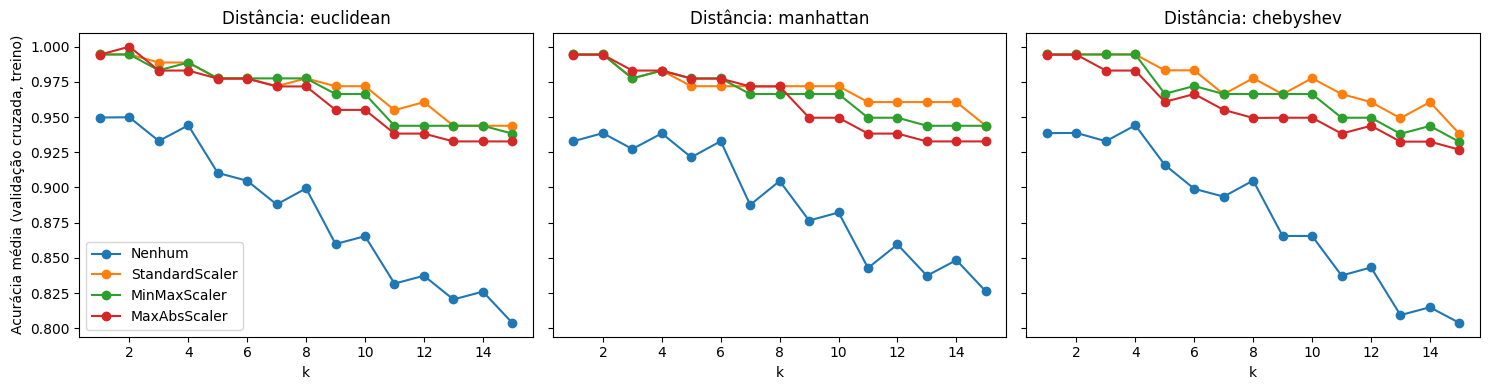

In [29]:
fig, eixos = plt.subplots(1, len(distancias), figsize=(15, 4), sharey=True)

for eixo, dist in zip(eixos, distancias):
    subset = df_resultados[df_resultados["distancia"] == dist]
    for nome_norm in normalizadores:
        dados = subset[subset["normalizacao"] == nome_norm]
        eixo.plot(dados["k"], dados["acuracia_media"], marker="o", label=nome_norm)
    eixo.set_title(f"Distância: {dist}")
    eixo.set_xlabel("k")

eixos[0].set_ylabel("Acurácia média (validação cruzada, treino)")
eixos[0].legend()
plt.tight_layout()
plt.show()

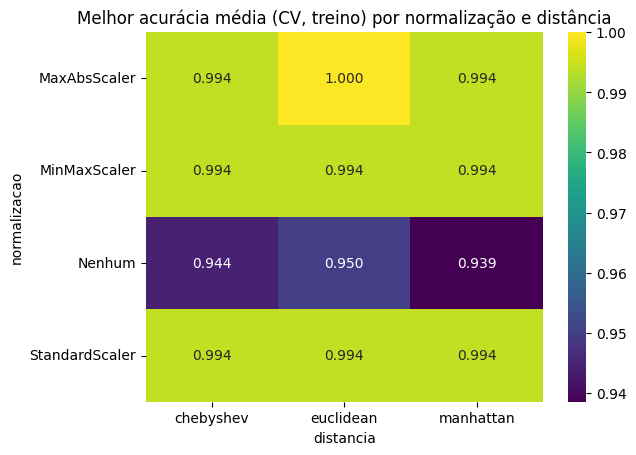

In [30]:
resumo = df_resultados.groupby(["normalizacao", "distancia"])["acuracia_media"].max().unstack()
sns.heatmap(resumo, annot=True, fmt=".3f", cmap="viridis")
plt.title("Melhor acurácia média (CV, treino) por normalização e distância")
plt.show()

<a id="conclusao"></a>
## 4. Conclusões e Principais Aprendizados

<a id="interacao"></a>
## 5. Descrição do uso de IA neste trabalho

$ \ \ \ \ \ $ Ao longo do desenvolvimento deste trabalho, foi utilizada a ferramenta de Inteligência Artificial Claude [[11]](#refs) como apoio em diferentes etapas do processo, como na depuração de código (debug), em que a IA foi utilizada para identificar a causa de diversos erros e avisos (warnings) encontrados durante a execução do notebook. Entre os principais casos, destacam-se: um ValueError de valores NaN no KNeighborsClassifier, causado por uma célula que reintroduzia dados faltantes ao ser executada fora de ordem; um KeyError decorrente da tentativa de remover colunas já removidas em uma execução anterior da mesma célula; um DataConversionWarning gerado pelo formato incorreto do vetor de rótulos (y), resolvido com o uso do método .ravel(); e um problema no método rename(), no qual algumas colunas não eram renomeadas corretamente — utilizou-se a IA para investigar a causa, que se revelou uma divergência entre os nomes de coluna documentados no site do UCI Machine Learning Repository e os nomes efetivamente retornados pela biblioteca ucimlrepo (rbcc/wbcc, em vez de rc/wc).

$ \ \ \ \ \ $ Também foram esclarecidas dúvidas pontuais sobre o funcionamento de métodos e bibliotecas do scikit-learn, como a diferença entre aplicar a normalização antes ou depois da divisão treino-teste (evitando vazamento de dados), o uso do Pipeline para garantir que o StandardScaler fosse reajustado a cada iteração da validação cruzada, e o funcionamento do cross_val_score em conjunto com o StratifiedKFold para obter estimativas de desempenho mais robustas do que as fornecidas por uma única divisão treino-teste.

$ \ \ \ \ \ $ Para a etapa de pré-processamento e análise exploratória, a IA auxiliou na identificação do conjunto de dados Chronic Kidney Disease e na forma correta de importá-lo por meio da biblioteca ucimlrepo, além de sugerir representações gráficas relevantes para a compreensão do problema, como o mapa de valores faltantes, os boxplots comparando atributos numéricos entre as classes do target, os gráficos de barras para os atributos categóricos e a matriz de correlação entre os atributos numéricos.

$ \ \ \ \ \ $ Por fim, no que se refere à análise de variação de hiperparâmetros, a IA foi utilizada para estruturar para auxiliar a construção dos gráficos comparativos de desempenho entre as combinações de diferentes valores de número de vizinhos (k), diferentes funções de distância (euclidiana, manhattan e chebyshev) e diferentes formas de normalização dos dados (nenhuma, StandardScaler, MinMaxScaler e MaxAbsScaler).

<a id="refs"></a>
## 6. Referências

[1] GBD 2023 CHRONIC KIDNEY DISEASE COLLABORATORS. Global, regional, and national burden of chronic kidney disease in adults, 1990–2023, and its attributable risk factors: a systematic analysis for the Global Burden of Disease Study 2023. **The Lancet**, v. 406, n. 10518, p. 2461-2482, 2025. DOI: 10.1016/S0140-6736(25)01853-7. Disponível em: https://www.thelancet.com/journals/lancet/article/PIIS0140-6736(25)01853-7/fulltext. Acesso em: 10 ago. 2026.

[2] RUBINI, L.; SOUNDARAPANDIAN, P.; ESWARAN, P. Chronic Kidney Disease [Dataset]. UCI Machine Learning Repository, 2015. Disponível em: https://doi.org/10.24432/C5G020. Acesso em: 17 ago. 2026.

[3] CASSAR, Daniel R. Aprendizado de máquina, k-NN e métricas. 2026. Jupyter Notebook. Material didático não publicado.

[4] CASSAR, Daniel R. Divisão de dados em treino e teste. 2026. Jupyter Notebook. Material didático não publicado.

[5] CASSAR, Daniel R. Modelo linear e baseline. 2026. Jupyter Notebook. Material didático não publicado.

[6] MATPLOTLIB DEVELOPMENT TEAM. Matplotlib Pyplot tutorial. Disponível em: https://matplotlib.org/stable/tutorials/pyplot.html. Acesso em: 10 ago. 2026.

[7] NUMPY DEVELOPERS. NumPy documentation. Disponível em: https://numpy.org/doc/. Acesso em: 10 ago. 2026.

[8] PANDAS DEVELOPMENT TEAM. pandas documentation. Disponível em: https://pandas.pydata.org/docs/. Acesso em: 10 ago. 2026.

[9] SEABORN DEVELOPMENT TEAM. seaborn: statistical data visualization. Disponível em: https://seaborn.pydata.org/. Acesso em: 10 ago. 2026.

[10] SCIKIT-LEARN DEVELOPERS. scikit-learn: machine learning in Python. Disponível em: https://scikit-learn.org/stable/. Acesso em: 10 ago. 2026.

[11] ANTHROPIC. Claude (Sonnet 5). São Francisco: Anthropic, 2026. Disponível em: https://claude.ai. Acesso em: 10 ago. 2026.

P.S. As referências estão ordenadas em ordem de aparição no documento.